### Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Extracción de datos

In [2]:
df = pd.read_excel('datos/Laboratorio 2. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx')
df.to_csv('datos/datos_lab2.csv', index=False)
df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


### Análisis exploratorio

In [19]:
# Adaptación de columna de fecha para análisis de series de tiempo
df["fecha"] = pd.to_datetime({
    "year": df["Año"],
    "month": df["Mes cod"],
    "day": 1 #utilizado por pd.to_datetime para crear una fecha completa (no se toma en cuenta)
})

df["Viajero"] = df["Viajero"].astype(int)

viajeros_por_mes = df.groupby("fecha")["Viajero"].sum()


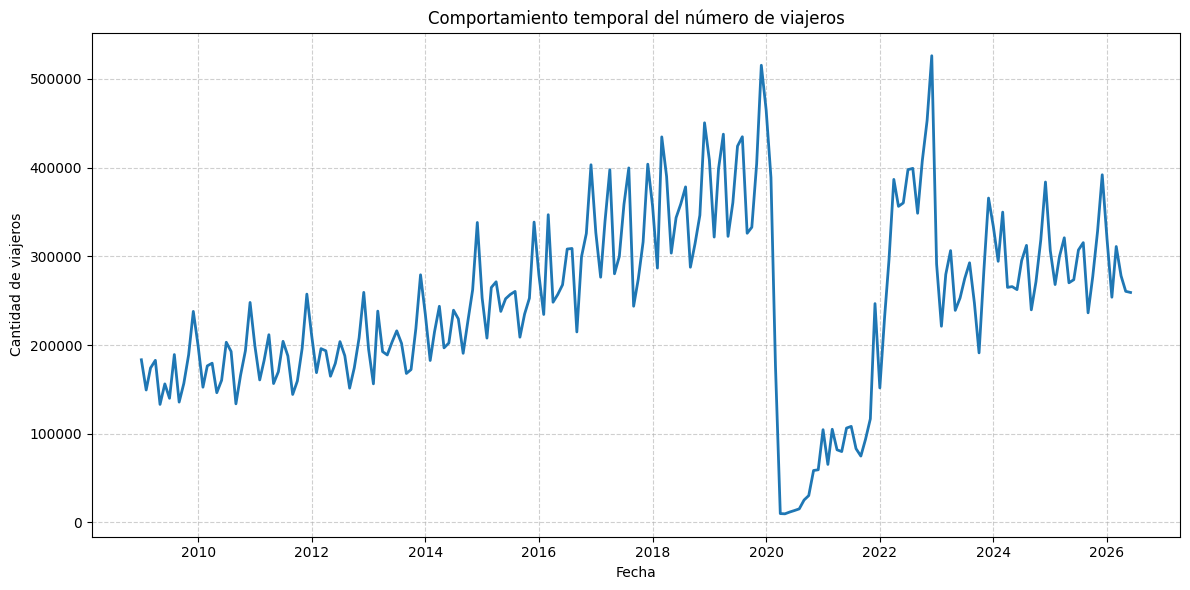

In [ ]:
# Comportamiento temporal de número de viajeros

plt.figure(figsize=(12,6))

plt.plot(viajeros_por_mes.index, viajeros_por_mes.values, linewidth=2)

plt.title("Comportamiento temporal del número de viajeros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Los 10 países con más viajeros
paises_con_mas_viajeros = df.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(10)
print("Países con más viajeros:")
print(paises_con_mas_viajeros)

Países con más viajeros:
País
El Salvador                  16212162
Guatemala                    14790279
Estados Unidos de América     7046014
Honduras                      2786735
México                        1807111
Belice                        1327627
Nicaragua                     1163521
Cruceristas                   1078335
Costa Rica                     881399
Colombia                       560767
Name: Viajero, dtype: int64


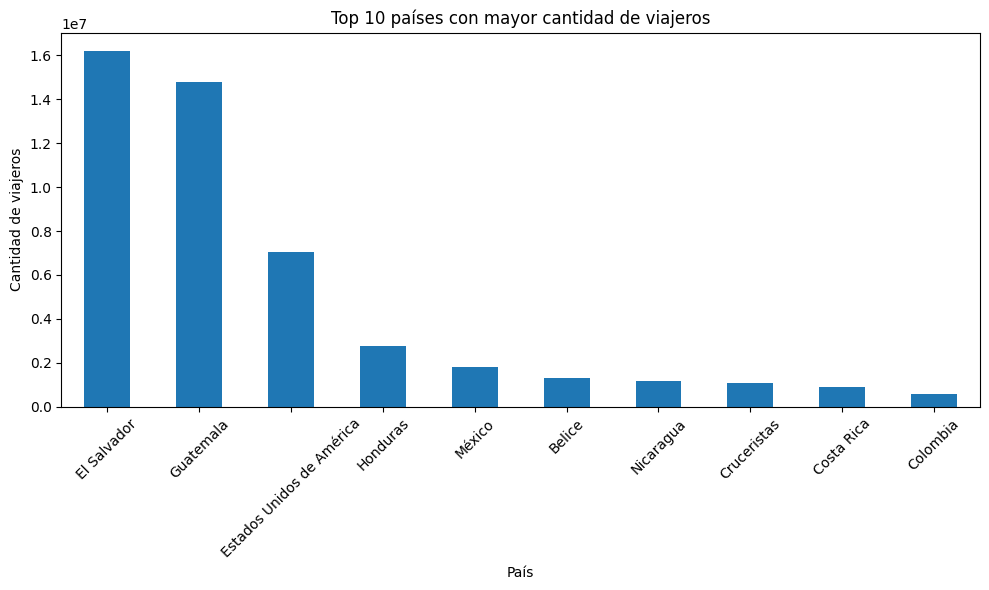

In [ ]:
# Gráfico de barras de los 10 países con más viajeros

plt.figure(figsize=(10,6))

paises_con_mas_viajeros.plot(kind="bar")

plt.title("Top 10 países con mayor cantidad de viajeros")
plt.xlabel("País")
plt.ylabel("Cantidad de viajeros")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Regiones con más viajeros
regiones_con_mas_viajeros = df.groupby("Región")["Viajero"].sum().sort_values(ascending=False).head(10)
print("Regiones con más viajeros:")
print(regiones_con_mas_viajeros)

Regiones con más viajeros:
Región
AMÉRICA DEL CENTRO        37398261
AMÉRICA DEL NORTE          9377992
EUROPA                     1902638
AMÉRICA DEL SUR            1299031
Cruceristas                1078335
OTROS EUROPEOS              313827
ASIA                        242583
OTROS PAISES DEL MUNDO      154663
OCEANÍA                     134619
ORIENTE MEDIO               127433
Name: Viajero, dtype: int64


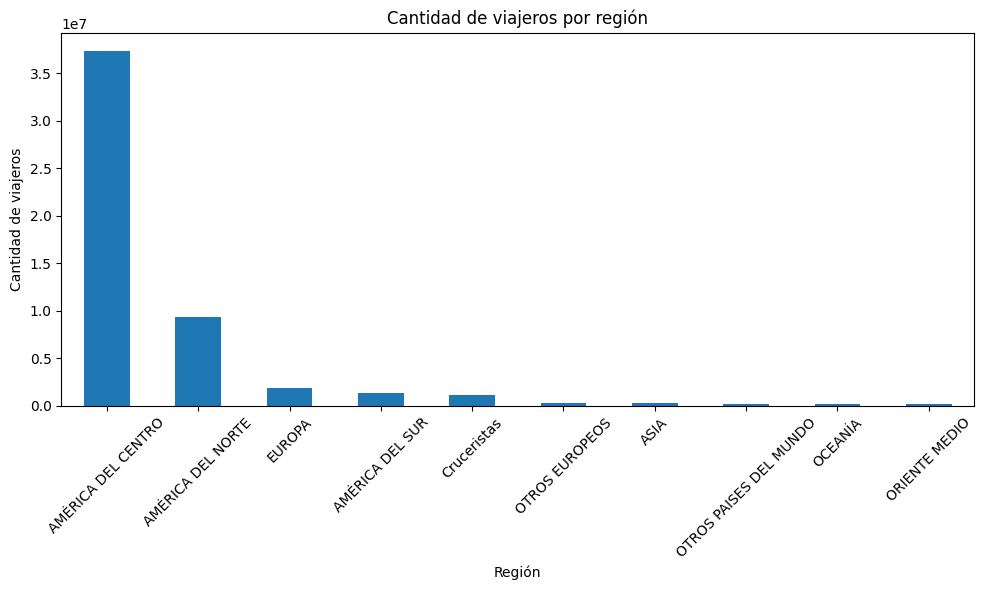

In [25]:
# Gráfico de barras de las regiones con más viajeros
plt.figure(figsize=(10,6))

regiones_con_mas_viajeros.plot(kind="bar")

plt.title("Cantidad de viajeros por región")
plt.xlabel("Región")
plt.ylabel("Cantidad de viajeros")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# Vías de ingreso
vias_de_ingreso = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
print("Vías de ingreso con más viajeros:")
print(vias_de_ingreso)

Vías de ingreso con más viajeros:
Vía
Terrestre    31972177
Aérea        19061290
Marítima      1228745
Name: Viajero, dtype: int64


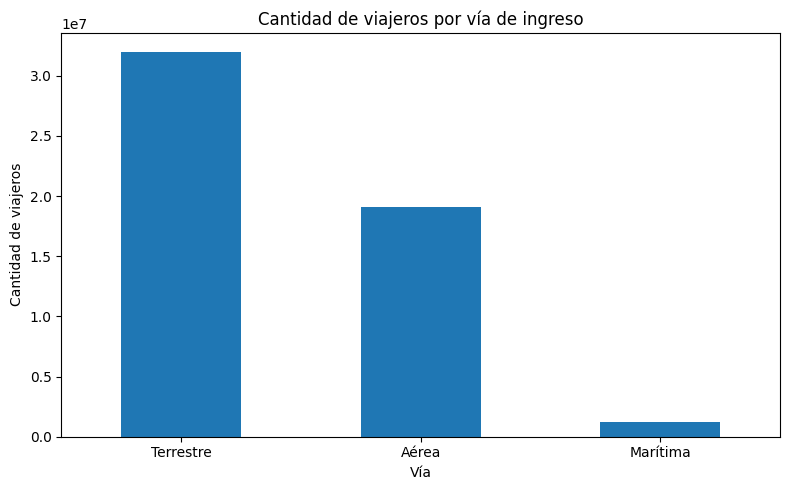

In [28]:
# Gráfico de barras de las vías con más ingresos
plt.figure(figsize=(8,5))

vias_de_ingreso.plot(kind="bar")

plt.title("Cantidad de viajeros por vía de ingreso")
plt.xlabel("Vía")
plt.ylabel("Cantidad de viajeros")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# Fronteras
fronteras = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False)
print("Fronteras con más viajeros:")
print(fronteras)

Fronteras con más viajeros:
Frontera
01 La Aurora                     19032087
07 Valle Nuevo                   10730106
09 San Cristóbal                  5361303
08 Pedro de Alvarado              4391523
10 La Ermita (Nueva Anguiatú)     2877716
20 Melchor de Mencos              2347125
13 El Cinchado / El Corinto       1494969
12 El Florido                     1218868
11 Agua Caliente                  1153224
15 El Carmen                      1021389
03 Puerto Quetzal                  741497
14 Tecún Umán                      653443
16 La Mesilla                      470141
04 Santo Tomás de Castilla         347359
19 Gracias a Dios                  122593
17 El Naranjo                       64750
05 Puerto Barrios                   62242
18 Bethel                           60163
06 Livingston                       51617
02 Mundo Maya                       34018
Cruceros                            26030
22 Otra frontera                       49
Name: Viajero, dtype: int64


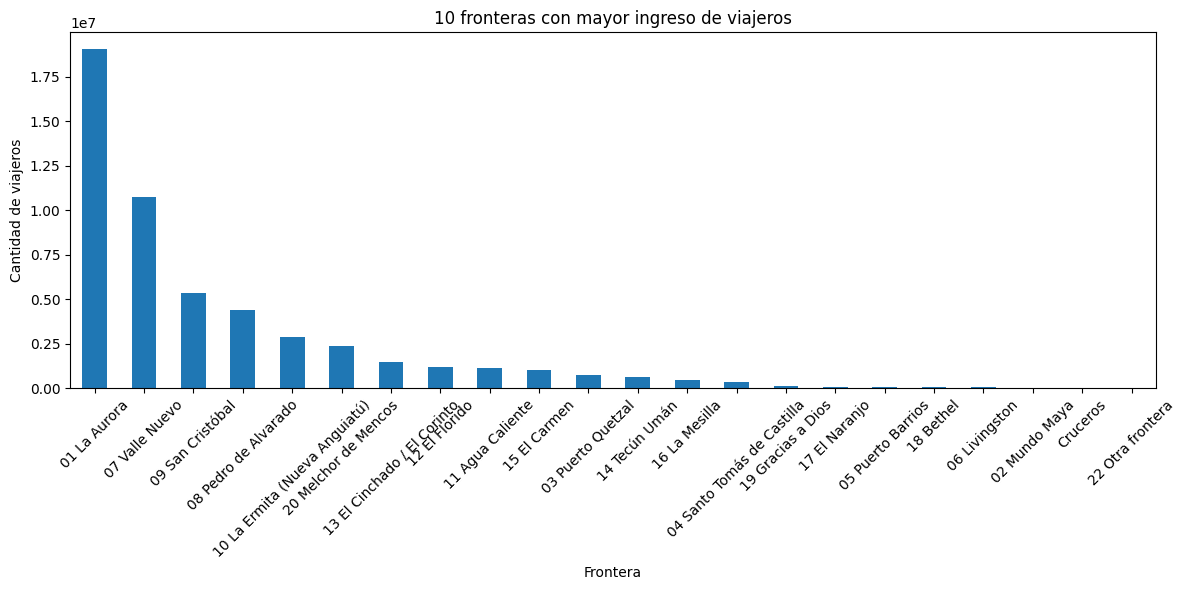

In [30]:
# Gráfico de barras de las fronteras más utilizadas
plt.figure(figsize=(12,6))

fronteras.plot(kind="bar")

plt.title("10 fronteras con mayor ingreso de viajeros")
plt.xlabel("Frontera")
plt.ylabel("Cantidad de viajeros")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Análisis de valores faltantes, duplicados y atípicos
df.info()
print("\nValores faltantes por columna:")
print(df.isnull().sum() / len(df) * 100)  # Porcentaje de valores faltantes por columna
print("\nDescripción estadística:")
print(df.describe())
print("\nValores duplicados:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Año                    161036 non-null  int64         
 1   Mes cod                161036 non-null  int64         
 2   Mes                    161036 non-null  object        
 3   Vía                    161036 non-null  object        
 4   Frontera               161036 non-null  object        
 5   País                   161036 non-null  object        
 6   Región                 161036 non-null  object        
 7   Región dos             161036 non-null  object        
 8   Regiones OMT           161036 non-null  object        
 9   MCEO                   161036 non-null  object        
 10  Agrupación Residencia  161036 non-null  object        
 11  Tipo de Viajero        161036 non-null  object        
 12  Viajero                161036 non-null  int6